In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
s3_path = "s3://ccai-bstn-bucket/google_ngrams/data_filtered.csv"
df_local = pd.read_csv(s3_path)
df_local.head(10)

/opt/anaconda3/envs/cloud_env/lib/python3.11/site-packages/fsspec/registry.py:275: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,token,year,frequency,pages,books
0,token,year,frequency,pages,books
1,data,1584,16,14,1
2,data,1614,3,2,1
3,data,1627,1,1,1
4,data,1631,22,18,1
5,data,1637,1,1,1
6,data,1638,2,2,1
7,data,1640,1,1,1
8,data,1642,1,1,1
9,data,1644,4,4,1


In [3]:
df_local = df_local[df_local["token"] != "token"].copy()

df_local["year"] = pd.to_numeric(df_local["year"])
df_local["frequency"] = pd.to_numeric(df_local["frequency"])
df_local["pages"] = pd.to_numeric(df_local["pages"])
df_local["books"] = pd.to_numeric(df_local["books"])

df_local = df_local.sort_values("year")
df_local.head()

,token,year,frequency,pages,books
1,data,1584,16,14,1
2,data,1614,3,2,1
3,data,1627,1,1,1
4,data,1631,22,18,1
5,data,1637,1,1,1


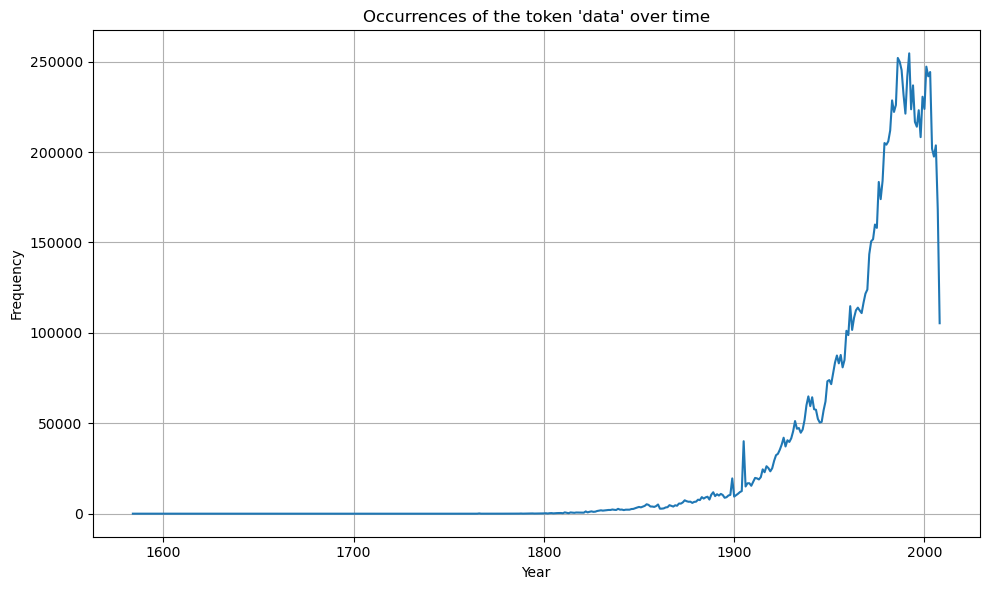

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(df_local["year"], df_local["frequency"])
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Occurrences of the token 'data' over time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
print(df_local.shape)
print(df_local["year"].min(), df_local["year"].max())
print(df_local["frequency"].max())

(316, 5)
1584 2008
254561
